# Error scaling analysis: final figures

All error metrics are computed from the validation predictions stored in
`predictions/scenario_XXX_<size>.npz` (`val_preds`, `val_targets`; shape `(N, T, Z, X, 2)`,
channel 0 = concentration, channel 1 = hydraulic head). Metadata (parameter counts, `beta_c`, `D_c`)
comes from `sweep_results.csv` and the dataset manifest. Section 1 is the only exception: the npz files
contain no epoch information, so it reads the per-epoch loss-history JSON files.

1. Loss vs epoch per model size
2. Error scaling per scenario: (2a-2e) separate metrics, grouped by channel
3. Theory fits (orange: $a$ fixed, green: $K$ and $a$ free, red: bound $K^*$)
4. $\beta_C$ vs fitted $A$, $a$, $A^*$ (colour = $D_C$)

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, curve_fit

plt.style.use("default")

# ---- Paths ----
BASE_RESULTS_PATH = Path("/scratch/yl75/ak4177/results/groundwater/fno_3d_henry_sweep")
BASE_DATA_PATH = Path("/scratch/yl75/ak4177/data/simple_henry")
RUN_NAME = "grid_scenarios_ic_random_skip2_20x40"
DATASET_NAME = "grid_scenarios_ic_random_skip2_20x40"

results_path = BASE_RESULTS_PATH / RUN_NAME
data_path = BASE_DATA_PATH / DATASET_NAME
prediction_npz_dir = results_path / "predictions"
fig_dir = results_path / "figures" / "final"
fig_dir.mkdir(parents=True, exist_ok=True)

# ---- Grid / time step used for the norms ----
DX = 0.05
DZ = 0.05
DT = 1.0 / 50   # T = 2.0 days, 100 steps with skip = 2

N_COLS = 4          # scenario grid columns
EXCLUDE_SCENARIOS = [1, 2, 3, 4]   # dropped from every plot and fit
RECOMPUTE = False   # set True to ignore the cached metrics CSV
metrics_cache = results_path / "npz_metrics.csv"

In [2]:
# ---- Metadata: model sizes and scenario parameters ----
sweep_df = pd.read_csv(results_path / "sweep_results.csv")
model_sizes = (
    sweep_df[["model_size_label", "total_params"]]
    .drop_duplicates()
    .sort_values("total_params")
    .reset_index(drop=True)
)
param_counts = model_sizes.set_index("model_size_label")["total_params"].to_dict()

manifest = json.load(open(data_path / "manifest.json"))["scenarios"]
scenarios_df = pd.DataFrame(manifest)[["scenario_index", "beta_c", "diffc"]]

model_sizes

,model_size_label,total_params
0,tiny,10070
1,small,67626
2,medium,1043826
3,large,8871906
4,huge,30453330


## Metric computation from npz files

In [3]:
def spatial_norms_sq(u):
    """Per-run (L^inf_t L^2_x)^2 and int_t ||grad u||_2^2 dt for u of shape (N, T, Z, X)."""
    area = DZ * DX
    l2_sq_space = np.sum(u ** 2, axis=(2, 3)) * area
    gz, gx = np.gradient(u, DZ, DX, axis=(2, 3))
    grad_sq_space = np.sum(gz ** 2 + gx ** 2, axis=(2, 3)) * area
    return np.max(l2_sq_space, axis=1), np.sum(grad_sq_space, axis=1) * DT


def head_sup_h1_norm(u):
    """Per-run sup_t ||u(t)||_{H^1} for u of shape (N, T, Z, X)."""
    area = DZ * DX
    l2_sq_space = np.sum(u ** 2, axis=(2, 3)) * area
    gz, gx = np.gradient(u, DZ, DX, axis=(2, 3))
    grad_sq_space = np.sum(gz ** 2 + gx ** 2, axis=(2, 3)) * area
    return np.max(np.sqrt(l2_sq_space + grad_sq_space), axis=1)


def rel_l2(target, pred):
    """Per-run relative L2 error over all of (T, Z, X); returns shape (N,)."""
    n = target.shape[0]
    diff = np.linalg.norm((pred - target).reshape(n, -1), axis=1)
    return diff / (np.linalg.norm(target.reshape(n, -1), axis=1) + 1e-12)


def compute_metrics(targets, preds):
    """All metrics for one (scenario, model) pair, each averaged over validation runs.

    Concentration norm  ||C||_{C_T}^2 = (L^inf L^2)^2 + int ||grad C||^2 dt.
    The two concentration components are normalised by the *full* true-solution norm, so
    conc_linf_l2^2 + conc_grad^2 = conc_norm^2.
    Head component is the relative sup_t H^1 norm. total_norm = conc_norm + head_norm.
    """
    t_c, p_c = targets[..., 0].astype(np.float64), preds[..., 0].astype(np.float64)
    t_h, p_h = targets[..., 1].astype(np.float64), preds[..., 1].astype(np.float64)

    linf_d, grad_d = spatial_norms_sq(p_c - t_c)
    linf_t, grad_t = spatial_norms_sq(t_c)
    true_c = np.sqrt(linf_t + grad_t)

    conc_norm = np.sqrt(linf_d + grad_d) / true_c
    head_norm = head_sup_h1_norm(p_h - t_h) / head_sup_h1_norm(t_h)

    return {
        "conc_rel_l2": rel_l2(t_c, p_c).mean(),
        "head_rel_l2": rel_l2(t_h, p_h).mean(),
        "conc_linf_l2": (np.sqrt(linf_d) / true_c).mean(),
        "conc_grad": (np.sqrt(grad_d) / true_c).mean(),
        "head_norm": head_norm.mean(),
        "conc_norm": conc_norm.mean(),
        "total_norm": (conc_norm + head_norm).mean(),
    }

In [4]:
if metrics_cache.exists() and not RECOMPUTE:
    metrics_df = pd.read_csv(metrics_cache)
else:
    rows = []
    for npz_file in sorted(prediction_npz_dir.glob("scenario_*.npz")):
        parts = npz_file.stem.split("_")
        scenario_index, size_label = int(parts[1]), parts[-1]
        with np.load(npz_file) as data:
            targets, preds = data["val_targets"], data["val_preds"]
        rows.append({"scenario_index": scenario_index, "model_size_label": size_label,
                     **compute_metrics(targets, preds)})
        print(f"done {npz_file.name}")
    metrics_df = pd.DataFrame(rows)
    metrics_df.to_csv(metrics_cache, index=False)

metrics_df = (
    metrics_df
    .merge(scenarios_df, on="scenario_index", how="left")
    .assign(total_params=lambda d: d["model_size_label"].map(param_counts))
    .query("scenario_index not in @EXCLUDE_SCENARIOS")
    .sort_values(["scenario_index", "total_params"])
    .reset_index(drop=True)
)
scenario_indices = sorted(metrics_df["scenario_index"].unique())
metrics_df.head()

,scenario_index,model_size_label,conc_rel_l2,head_rel_l2,conc_linf_l2,conc_grad,head_norm,conc_norm,total_norm,beta_c,diffc,total_params
0,5,tiny,0.216841,0.636335,0.066722,0.292463,0.637558,0.300272,0.937830,0.00002,0.001,10070
1,5,small,0.181805,0.436028,0.044010,0.203494,0.309180,0.208452,0.517632,0.00002,0.001,67626
2,5,medium,0.079717,0.328410,0.019366,0.109815,0.181703,0.111735,0.293438,0.00002,0.001,1043826
3,5,large,0.051299,0.115980,0.012249,0.070047,0.089010,0.071272,0.160282,0.00002,0.001,8871906
4,5,huge,0.033576,0.073508,0.008266,0.047944,0.061957,0.048769,0.110726,0.00002,0.001,30453330


## Plot helpers and theory fits

In [5]:
# Theoretical bound: P(eps) = K * eps^-a * (1 + log(1/eps))^2, a = 16 from theory,
# i.e. log(P/K) = -a log(eps) + 2 log(1 - log(eps)).
THEORY_EXP = 16


def theory_log_P_over_K(eps, exponent=THEORY_EXP):
    log_eps = np.log(eps)
    return -exponent * log_eps + 2 * np.log1p(-log_eps)


def theory_eps_from_P(P, K, exponent=THEORY_EXP):
    """Invert the bound numerically (root-find in log(eps) to avoid overflow)."""
    targets = np.log(np.asarray(P, dtype=float)) - np.log(K)

    def solve(t):
        u = brentq(lambda u: -exponent * u + 2 * np.log1p(-u) - t, -1000.0, 1.0 - 1e-12)
        return np.exp(u)

    return np.vectorize(solve)(targets)


def theory_K_envelope(P, eps, exponent=THEORY_EXP):
    """Smallest K (a fixed) for which the bound lies above every empirical point."""
    P = np.asarray(P, dtype=float)
    eps = np.asarray(eps, dtype=float)
    return np.exp(np.max(np.log(P) - theory_log_P_over_K(eps, exponent)))


def fit_theory_K(P, eps, exponent=THEORY_EXP):
    """Least-squares fit of K only (exponent fixed), in log(eps)."""
    P = np.asarray(P, dtype=float)
    eps = np.asarray(eps, dtype=float)
    log_K0 = np.mean(np.log(P) - theory_log_P_over_K(eps, exponent))

    def model(P, log_K):
        return np.log(theory_eps_from_P(P, np.exp(log_K), exponent))

    popt, _ = curve_fit(model, P, np.log(eps), p0=[log_K0])
    return np.exp(popt[0])


def fit_theory_K_exponent(P, eps):
    """Least-squares fit of (K, a) in log(eps)."""
    P = np.asarray(P, dtype=float)
    eps = np.asarray(eps, dtype=float)
    log_eps = np.log(eps)
    a0, log_K0 = np.polyfit(-log_eps, np.log(P) - 2 * np.log1p(-log_eps), 1)
    a0 = max(a0, 1e-2)

    def model(P, log_K, exponent):
        return np.log(theory_eps_from_P(P, np.exp(log_K), exponent))

    popt, _ = curve_fit(model, P, log_eps, p0=[log_K0, a0],
                        bounds=([-np.inf, 1e-3], [np.inf, np.inf]))
    return np.exp(popt[0]), popt[1]


def plot_theory_overlay(ax, P, eps, show_fixed=True):
    """Overlay the three theory curves; returns the fitted parameters (NaN if a fit fails)."""
    P_grid = np.logspace(np.log10(min(P)), np.log10(max(P)), 200)
    out = {"K_fit_fixed_exp": np.nan, "K_fit": np.nan, "exponent_fit": np.nan, "K_envelope": np.nan}

    try:  # orange: exponent fixed, K fitted
        out["K_fit_fixed_exp"] = fit_theory_K(P, eps)
        if show_fixed:
            ax.plot(P_grid, theory_eps_from_P(P_grid, out["K_fit_fixed_exp"]), color="orange", linestyle="--",
                    label=f"Fit $K$ ($a$={THEORY_EXP}, $K$={out['K_fit_fixed_exp']:.2e})")
    except Exception as exc:
        print(f"  fixed-exponent fit failed: {exc}")

    try:  # green: K and exponent fitted
        out["K_fit"], out["exponent_fit"] = fit_theory_K_exponent(P, eps)
        ax.plot(P_grid, theory_eps_from_P(P_grid, out["K_fit"], out["exponent_fit"]), color="green", linestyle=":",
                label=f"Fit $K, a$ ($a$={out['exponent_fit']:.2f}, $K$={out['K_fit']:.2e})")
    except Exception as exc:
        print(f"  free fit failed: {exc}")

    try:  # red: smallest K for which the curve upper-bounds every point
        out["K_envelope"] = theory_K_envelope(P, eps)
        ax.plot(P_grid, theory_eps_from_P(P_grid, out["K_envelope"]), color="red", linestyle="-.",
                label=f"Bound ($a$={THEORY_EXP}, $K^*$={out['K_envelope']:.2e})")
    except Exception as exc:
        print(f"  envelope failed: {exc}")
    return out


def compute_rayleigh_number(beta_c, diffc):
    K, delta_c, H, eta = 50, 35, 1, 0.35
    return (K * beta_c * delta_c * H) / (eta * diffc)


def scenario_grid(metric, ylabel, title, fname, theory=False, logy=False, paper=False):
    """One subplot per scenario: validation error vs total parameters.

    paper=True gives a publication layout: no suptitle (goes in the caption), no orange fit,
    one shared legend, fitted parameters annotated in each panel, outer axis labels only,
    shared y-axis, and a PDF saved next to the PNG.
    Returns a DataFrame of fitted theory parameters (one row per scenario) when theory=True.
    """
    n = len(scenario_indices)
    n_rows = math.ceil(n / N_COLS)
    figsize = (3.1 * N_COLS, 2.5 * n_rows + 0.5) if paper else (4 * N_COLS, 2.2 * n_rows + 1)
    fit_rows = []

    with plt.rc_context({"font.size": 10} if paper else {}):
        fig, axes = plt.subplots(n_rows, N_COLS, figsize=figsize, sharex=True, sharey=paper,
                                 constrained_layout=True, squeeze=False)
        for ax in axes.flat[n:]:
            ax.set_visible(False)

        for i, (ax, s) in enumerate(zip(axes.flat, scenario_indices)):
            sub = metrics_df[metrics_df["scenario_index"] == s].sort_values("total_params")
            beta_c, diffc = sub["beta_c"].iloc[0], sub["diffc"].iloc[0]
            Ra = compute_rayleigh_number(beta_c, diffc)
            P, eps = sub["total_params"].to_numpy(), sub[metric].to_numpy()

            ax.plot(P, eps, color="blue", marker="o", label="Empirical")
            if theory:
                fit = plot_theory_overlay(ax, P, eps, show_fixed=not paper)
                fit_rows.append({"scenario_index": s, "beta_c": beta_c, "diffc": diffc, "Ra": Ra, **fit})
                if paper:
                    ax.text(0.04, 0.05,
                            f"$a$={fit['exponent_fit']:.2f}\n$A$={fit['K_fit']:.1e}\n$A^*$={fit['K_envelope']:.1e}",
                            transform=ax.transAxes, fontsize=8.5, va="bottom", ha="left",
                            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.9))
                else:
                    ax.legend(fontsize=6)

            ax.set_title(f"$\\beta_C={beta_c:g}$, $D_C={diffc:g}$, $R_a={Ra:g}$", fontsize=10 if paper else 9)
            on_bottom = (i + N_COLS >= n) if paper else True
            on_left = (i % N_COLS == 0) if paper else True
            ax.set_xlabel("Total Parameters" if on_bottom else "")
            ax.set_ylabel("" if paper else ylabel)
            ax.set_xscale("log")
            if logy:
                ax.set_yscale("log")
            ax.grid(True, which="both", linestyle="--", linewidth=0.5)
            if paper:
                ax.tick_params(labelbottom=on_bottom, labelleft=on_left)

        if paper:
            handles, _ = axes[0, 0].get_legend_handles_labels()
            fig.supylabel(ylabel, fontsize=12)
            fig.legend(handles, ["Empirical", "Fit ($A$, $a$ free)", "Bound ($a$=16, $A^*$)"],
                       loc="outside upper center", ncol=3, fontsize=11, frameon=False)
        else:
            fig.suptitle(title, fontsize=13)

        fig.savefig(fig_dir / fname, bbox_inches="tight", dpi=300)
        if paper:
            fig.savefig(fig_dir / Path(fname).with_suffix(".pdf"), bbox_inches="tight")
        plt.show()
        plt.close(fig)
    return pd.DataFrame(fit_rows) if theory else None


## 1. Loss vs epoch per model size

The sweep trains one model per size on all scenarios jointly and writes a single
`{size}_loss_history.json` per size. If several history files exist for a size
(`{size}*_loss_history.json`, e.g. repeated runs), the line is the mean and the band is min-max;
with a single file only the line is drawn.

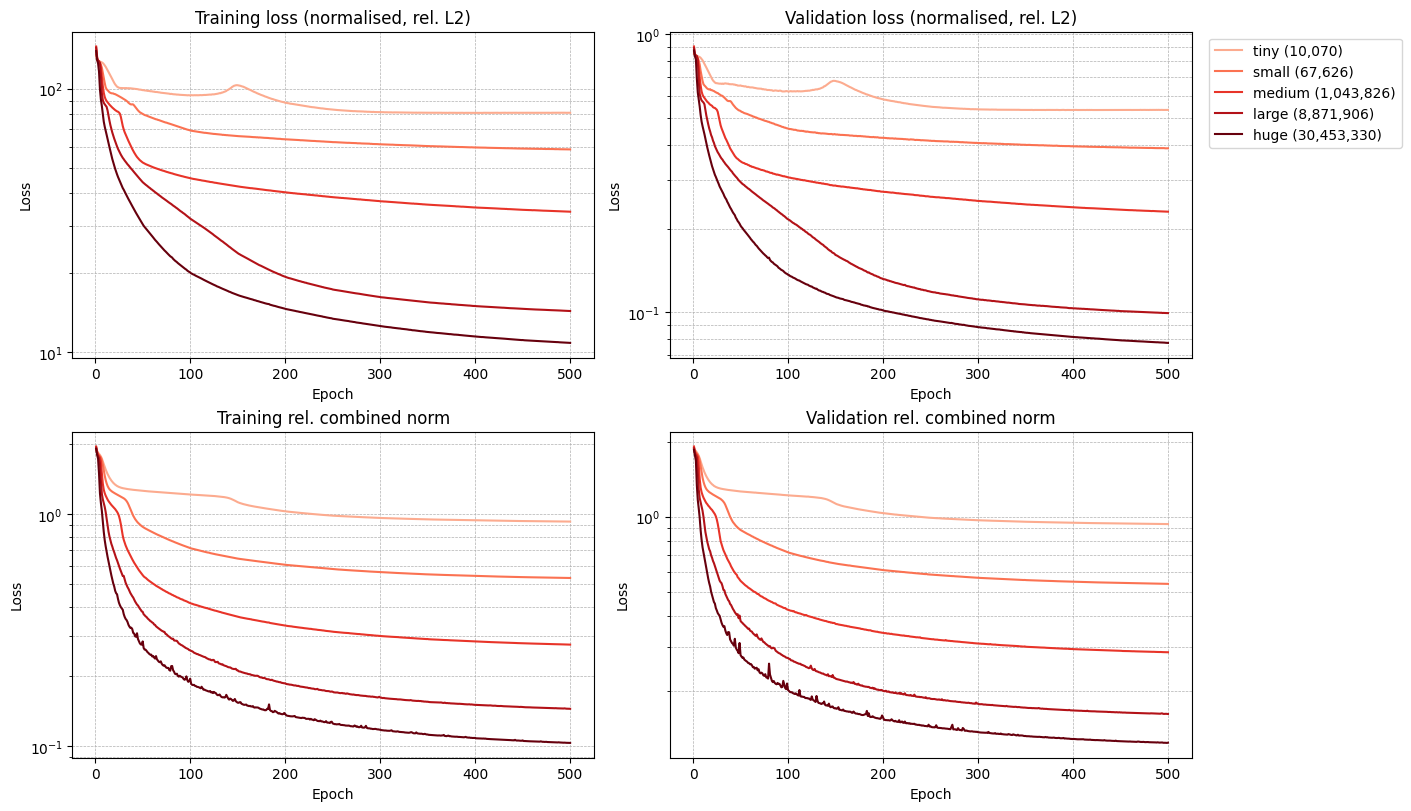

In [6]:
loss_dir = results_path / "figures"
colors = plt.cm.Reds(np.linspace(0.3, 1, len(model_sizes)))
history_panels = [
    ("train_loss_history", "Training loss (normalised, rel. L2)"),
    ("val_loss_history", "Validation loss (normalised, rel. L2)"),
    ("train_rel_combined_norm_history", "Training rel. combined norm"),
    ("val_rel_combined_norm_history", "Validation rel. combined norm"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

for color, (label, params) in zip(colors, model_sizes.itertuples(index=False)):
    files = sorted(loss_dir.glob(f"{label}*_loss_history.json"))
    if not files:
        print(f"no loss history for {label}")
        continue
    histories = [json.load(open(f)) for f in files]

    for ax, (key, title) in zip(axes.flat, history_panels):
        stack = np.array([h[key] for h in histories])   # (n_files, n_epochs)
        epochs = np.arange(1, stack.shape[1] + 1)
        ax.plot(epochs, stack.mean(axis=0), color=color, label=f"{label} ({params:,})")
        if len(stack) > 1:
            ax.fill_between(epochs, stack.min(axis=0), stack.max(axis=0), color=color, alpha=0.25)
        ax.set_title(title)

for ax in axes.flat:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
axes[0, 1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

fig.savefig(fig_dir / "loss_vs_epoch.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)

## 2. Error scaling per scenario

Each metric gets its own scenario grid. Concentration channel: 2a, 2c, 2d. Hydraulic head channel: 2b, 2e.
Components 2c and 2d are normalised by the full true concentration norm, so they combine in quadrature
to the concentration part of the total norm.

### Concentration channel

**2a.** Concentration relative L2 norm

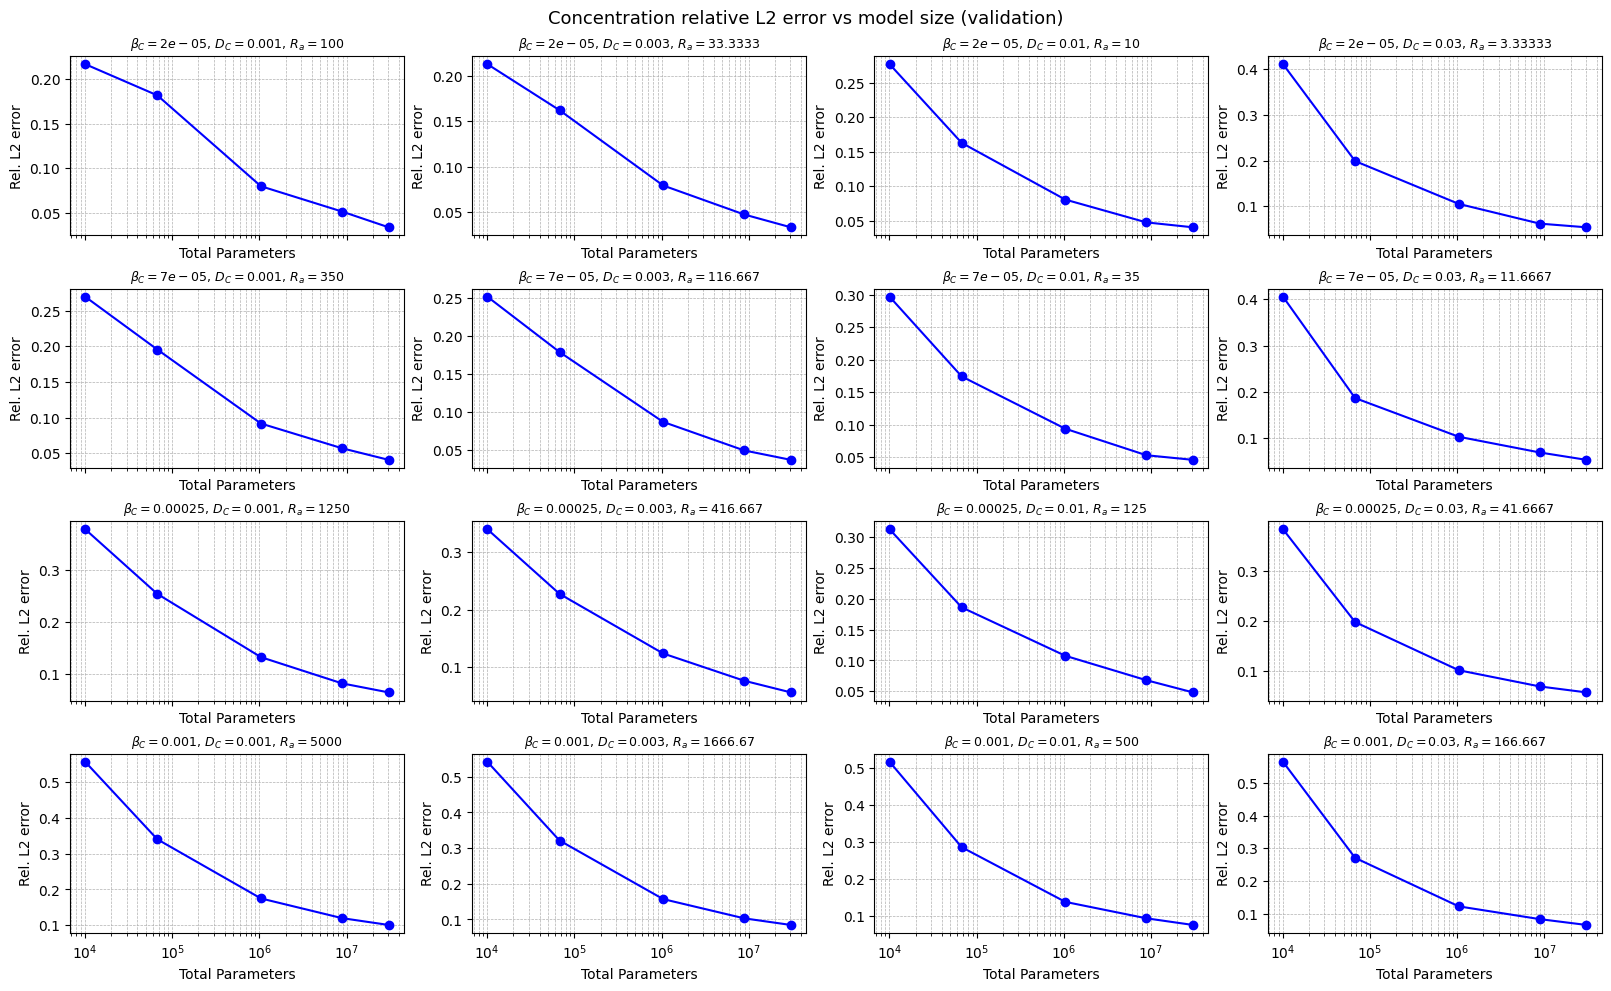

In [7]:
scenario_grid("conc_rel_l2", "Rel. L2 error",
              "Concentration relative L2 error vs model size (validation)",
              "scaling_2a_conc_rel_l2.png")

**2c.** $L^\infty L^2$ component of the concentration norm

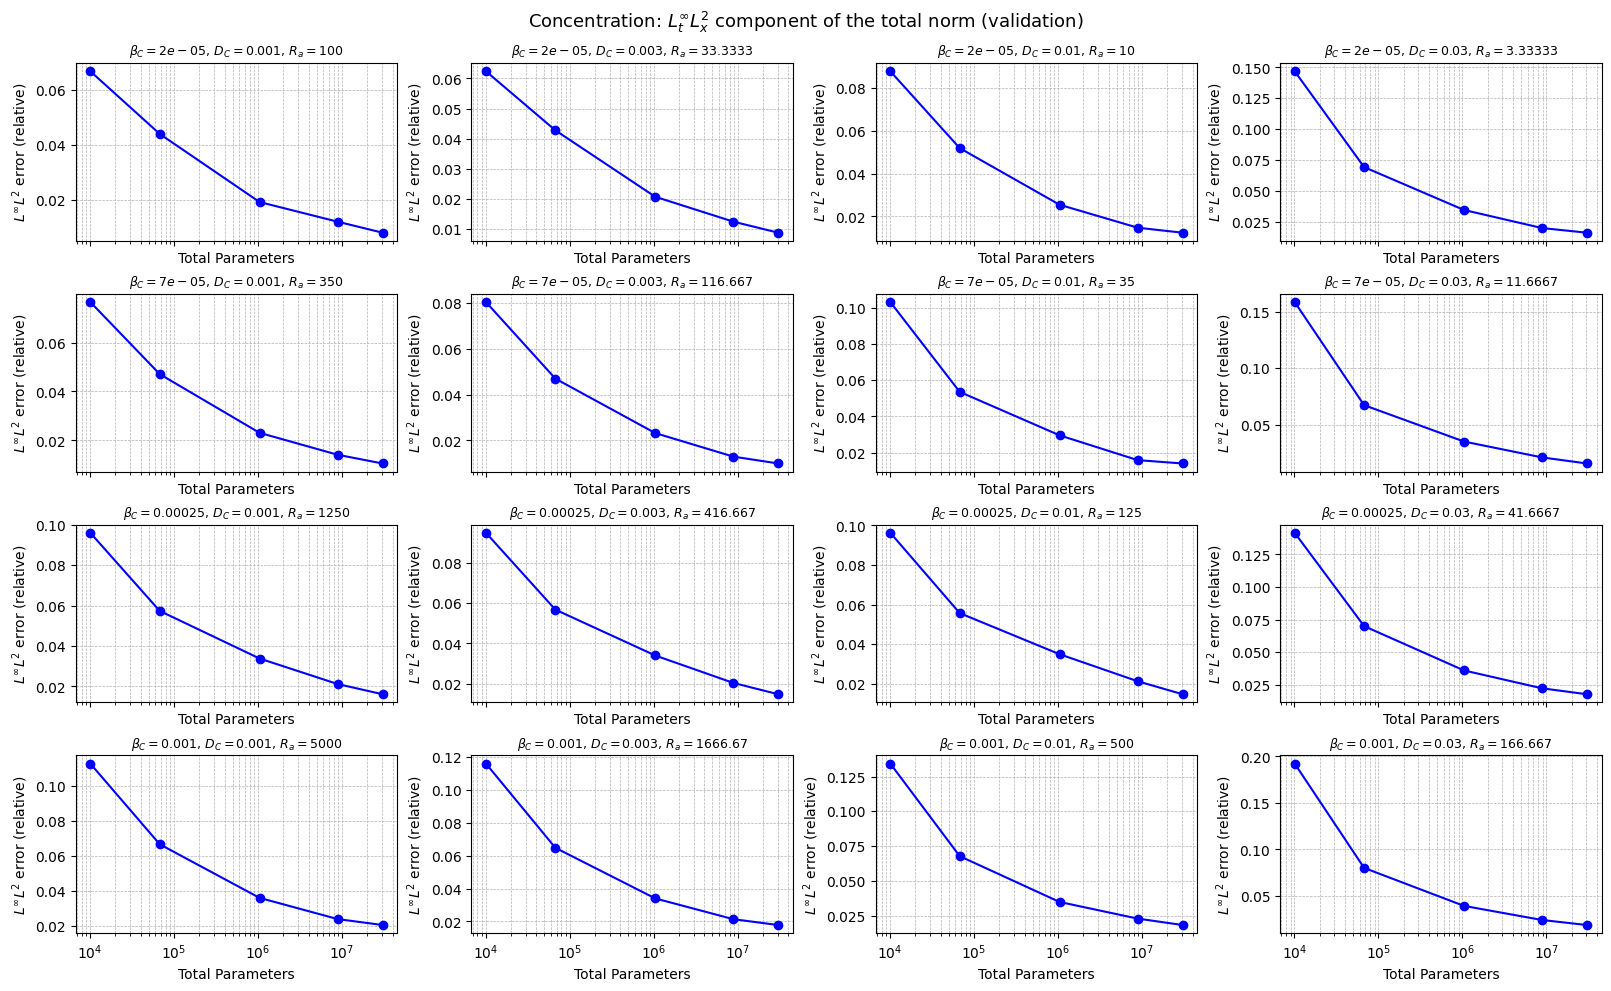

In [8]:
scenario_grid("conc_linf_l2", "$L^\\infty L^2$ error (relative)",
              "Concentration: $L^\\infty_t L^2_x$ component of the total norm (validation)",
              "scaling_2c_conc_linf_l2.png")

**2d.** Spatial-gradient component of the concentration norm

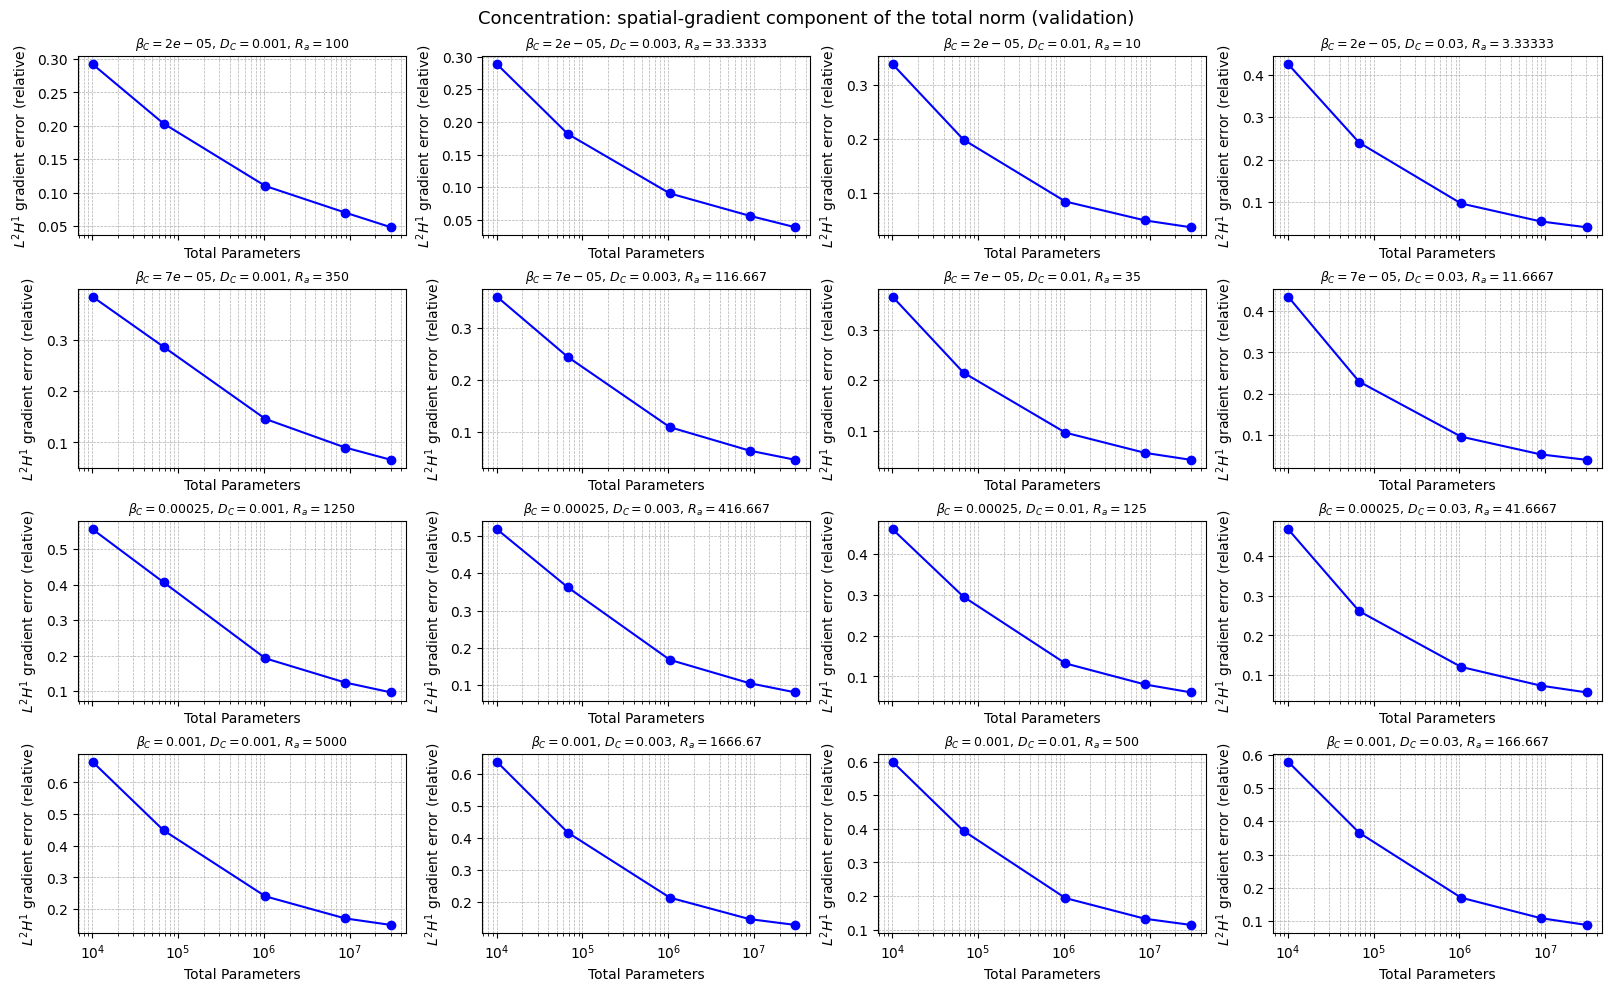

In [9]:
scenario_grid("conc_grad", "$L^2 H^1$ gradient error (relative)",
              "Concentration: spatial-gradient component of the total norm (validation)",
              "scaling_2d_conc_grad.png")

### Hydraulic head channel

**2b.** Hydraulic head relative L2 norm

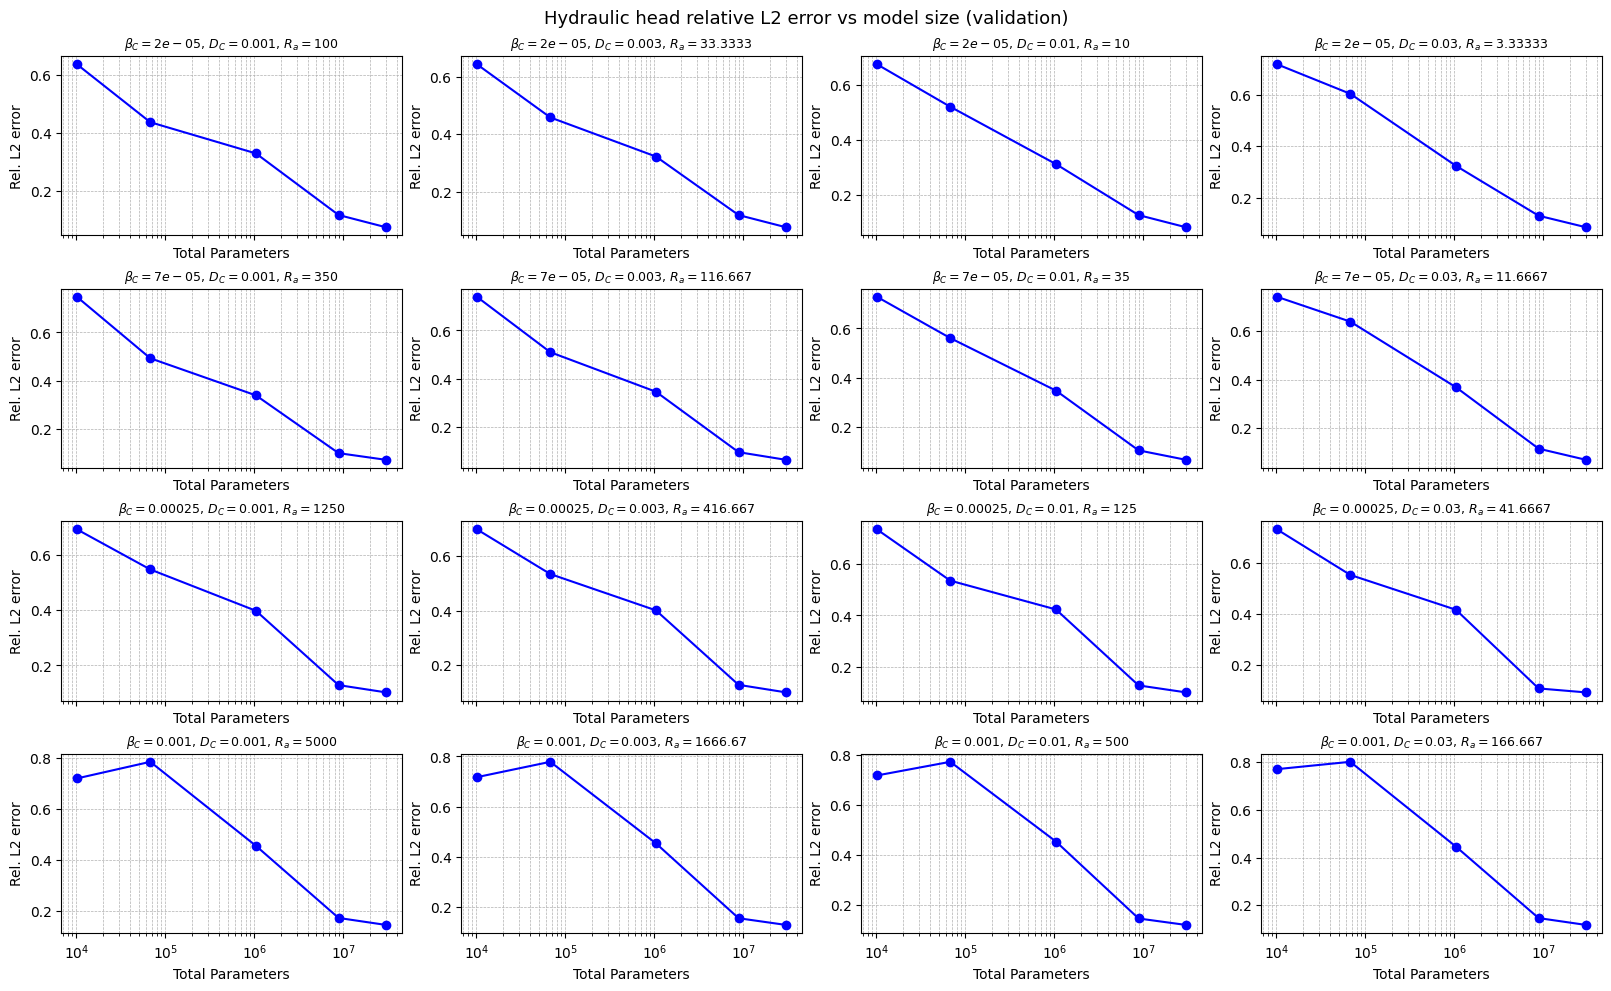

In [10]:
scenario_grid("head_rel_l2", "Rel. L2 error",
              "Hydraulic head relative L2 error vs model size (validation)",
              "scaling_2b_head_rel_l2.png")

**2e.** Hydraulic head component of the total norm ($\sup_t H^1$, relative)

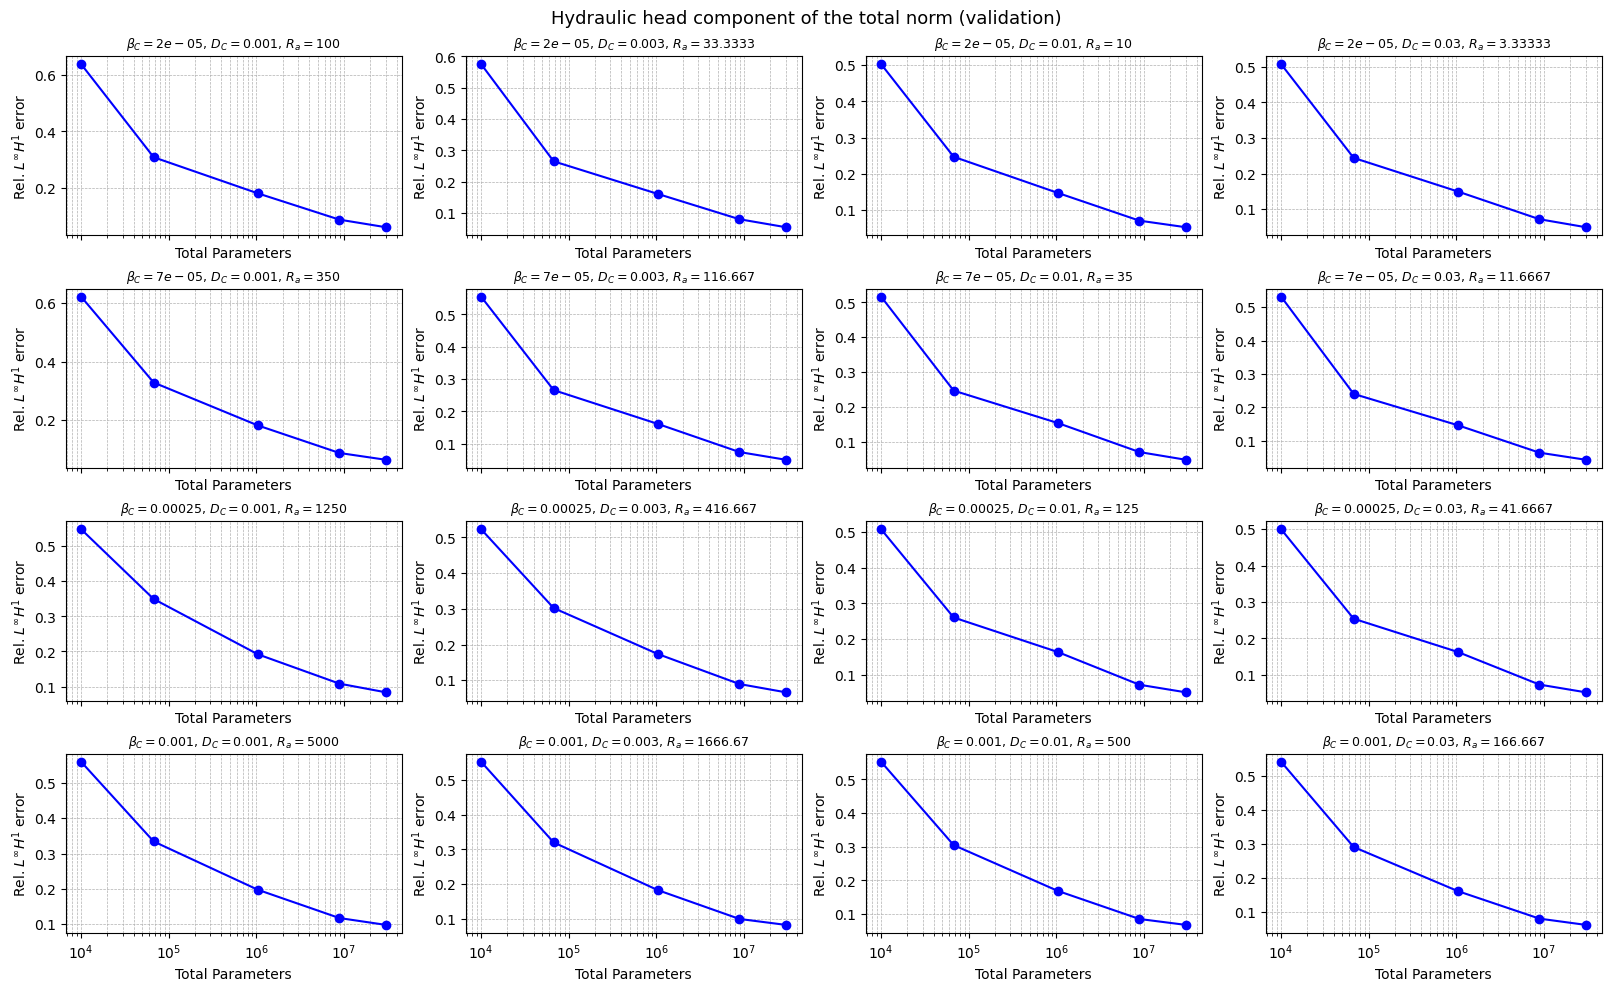

In [11]:
scenario_grid("head_norm", "Rel. $L^\\infty H^1$ error",
              "Hydraulic head component of the total norm (validation)",
              "scaling_2e_head_norm.png")

## 3. Theory fits

Orange: exponent fixed at $a=16$, $K$ fitted. Green: $K$ and $a$ fitted. Red: smallest $K^*$ ($a=16$)
whose curve upper-bounds every point.

**3a.** Concentration relative L2

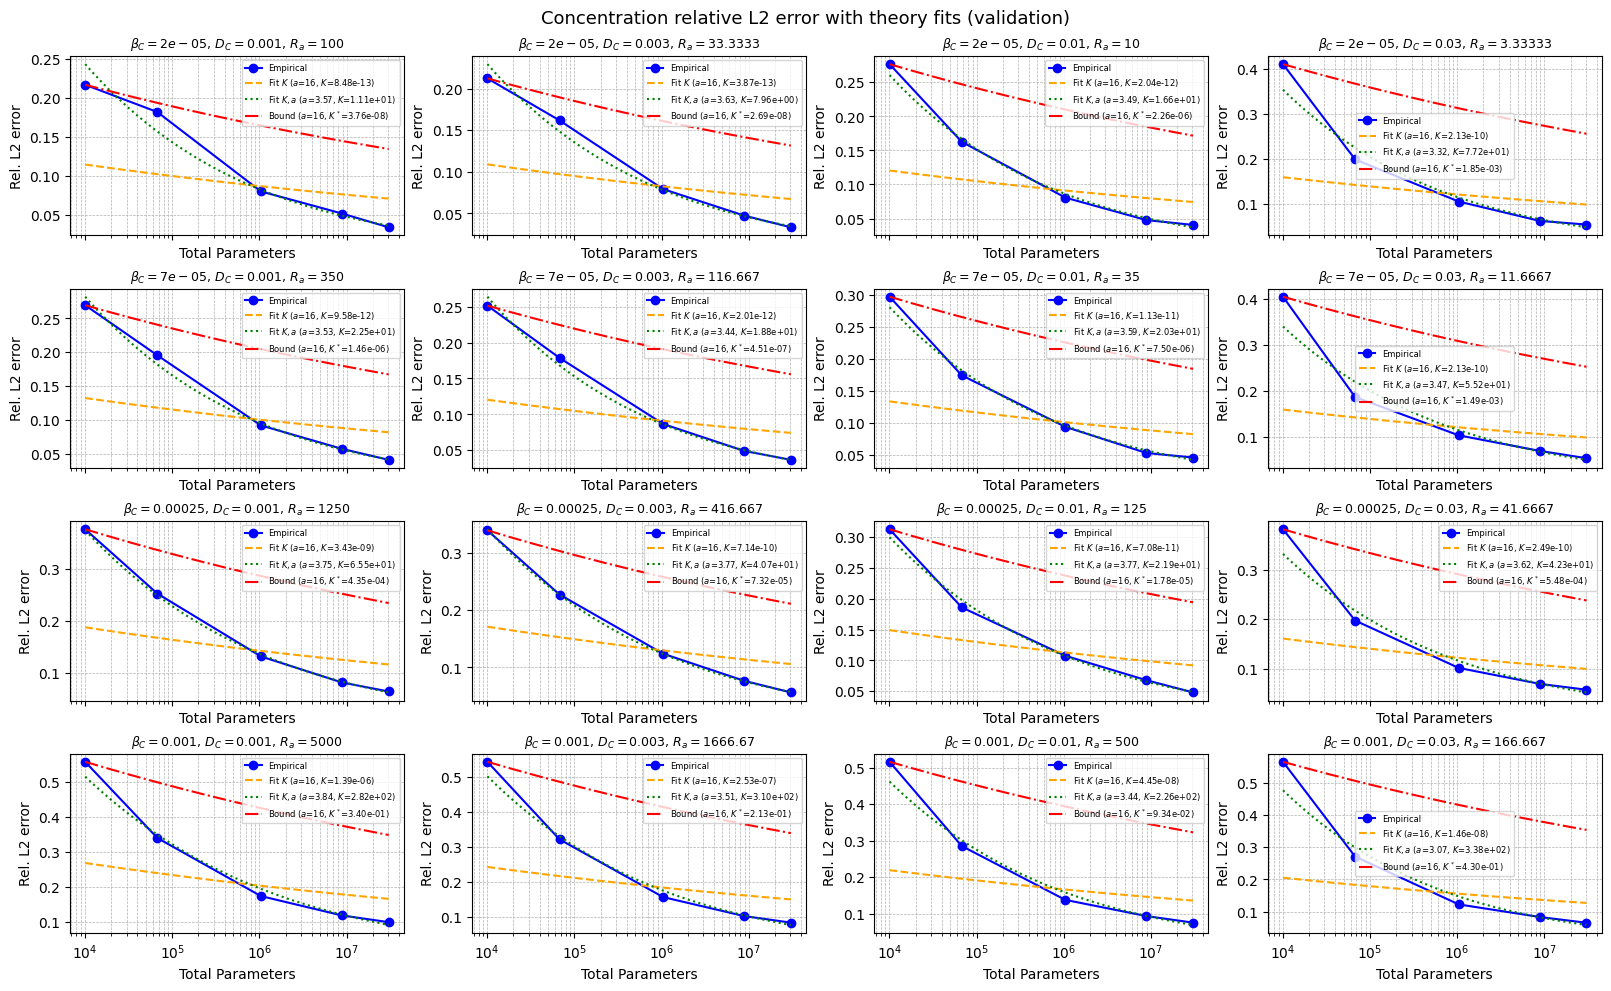

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,5,0.00002,0.001,100.000000,8.479242e-13,11.109594,3.571564,3.763123e-08
1,6,0.00002,0.003,33.333333,3.872275e-13,7.955689,3.626106,2.693464e-08
2,7,0.00002,0.010,10.000000,2.043648e-12,16.644885,3.494502,2.261422e-06
3,8,0.00002,0.030,3.333333,2.127368e-10,77.160141,3.316846,1.851421e-03
4,9,0.00007,0.001,350.000000,9.576317e-12,22.471996,3.531441,1.457493e-06
5,10,0.00007,0.003,116.666667,2.009086e-12,18.842861,3.441779,4.505303e-07
6,11,0.00007,0.010,35.000000,1.131534e-11,20.262434,3.594163,7.500469e-06
7,12,0.00007,0.030,11.666667,2.125171e-10,55.153860,3.474785,1.488030e-03
8,13,0.00025,0.001,1250.000000,3.430634e-09,65.453427,3.745123,4.346329e-04
9,14,0.00025,0.003,416.666667,7.142733e-10,40.668736,3.773145,7.319945e-05


In [12]:
fits_conc = scenario_grid("conc_rel_l2", "Rel. L2 error",
                          "Concentration relative L2 error with theory fits (validation)",
                          "theory_3a_conc_rel_l2.png", theory=True)
fits_conc

**3b.** Hydraulic head relative L2

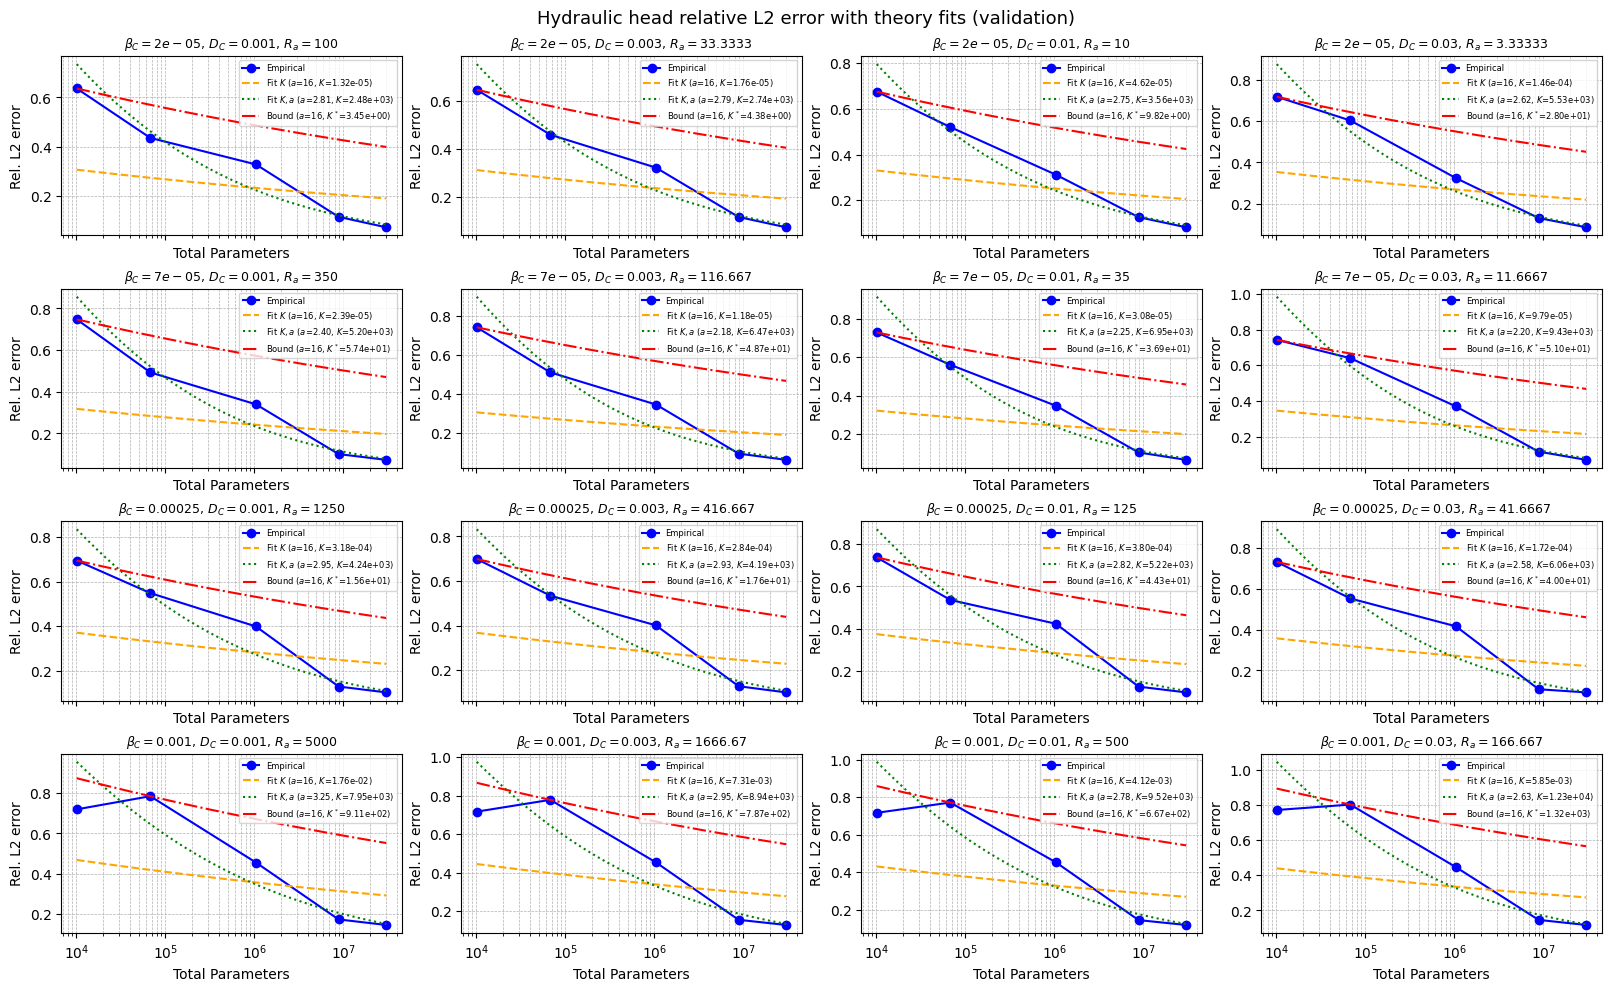

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,5,0.00002,0.001,100.000000,0.000013,2475.039767,2.813691,3.451876
1,6,0.00002,0.003,33.333333,0.000018,2743.863035,2.787805,4.376207
2,7,0.00002,0.010,10.000000,0.000046,3564.714651,2.753306,9.820683
3,8,0.00002,0.030,3.333333,0.000146,5527.300666,2.621112,28.012679
4,9,0.00007,0.001,350.000000,0.000024,5198.676314,2.404252,57.419520
5,10,0.00007,0.003,116.666667,0.000012,6474.573685,2.177553,48.676052
6,11,0.00007,0.010,35.000000,0.000031,6951.835376,2.249608,36.928528
7,12,0.00007,0.030,11.666667,0.000098,9430.771484,2.196327,51.020451
8,13,0.00025,0.001,1250.000000,0.000318,4237.024846,2.946274,15.623312
9,14,0.00025,0.003,416.666667,0.000284,4194.423669,2.934282,17.579358


In [13]:
fits_head = scenario_grid("head_rel_l2", "Rel. L2 error",
                          "Hydraulic head relative L2 error with theory fits (validation)",
                          "theory_3b_head_rel_l2.png", theory=True)
fits_head

**3c.** Combined total norm

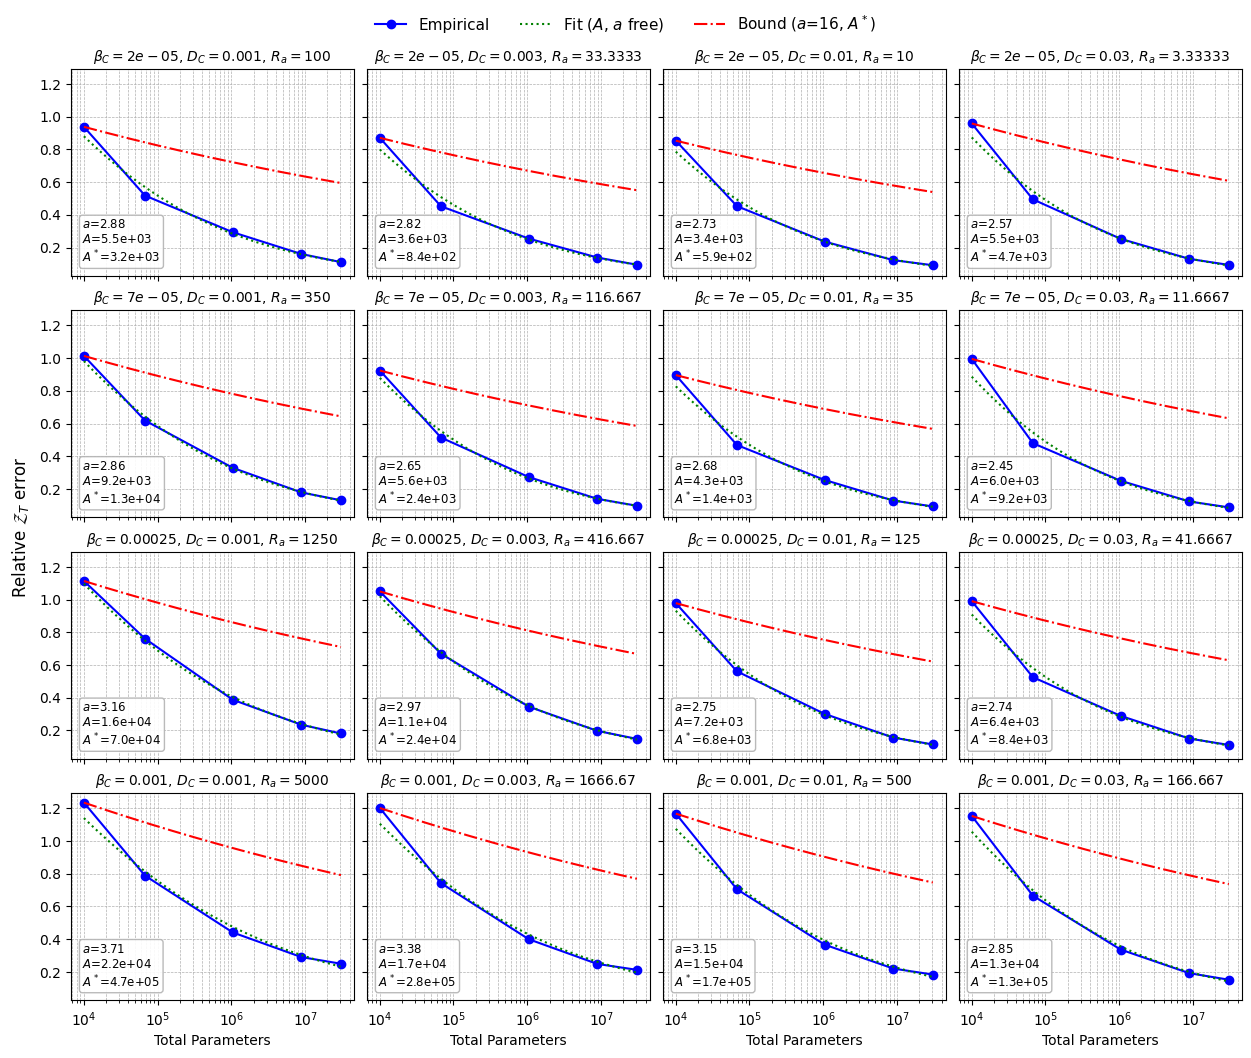

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,5,0.00002,0.001,100.000000,0.000701,5484.774627,2.875500,3184.048031
1,6,0.00002,0.003,33.333333,0.000078,3570.132611,2.822944,843.071494
2,7,0.00002,0.010,10.000000,0.000034,3388.069511,2.729363,591.599924
3,8,0.00002,0.030,3.333333,0.000111,5504.885124,2.567185,4690.703570
4,9,0.00007,0.001,350.000000,0.006171,9198.480832,2.864894,12783.202001
5,10,0.00007,0.003,116.666667,0.000205,5604.324490,2.651090,2439.490547
6,11,0.00007,0.010,35.000000,0.000071,4285.103568,2.678246,1410.549062
7,12,0.00007,0.030,11.666667,0.000072,5962.859816,2.446780,9199.237219
8,13,0.00025,0.001,1250.000000,0.228544,16345.939174,3.159463,70396.003131
9,14,0.00025,0.003,416.666667,0.022608,11113.748058,2.970811,24025.519955


In [14]:
fits_total = scenario_grid("total_norm", r"Relative $\mathcal{Z}_T$ error",
                           "Combined total-norm error with theory fits (validation)",
                           "theory_3c_total_norm.png", theory=True, paper=True)
fits_total

**3d.** Concentration component of the total norm, $\|C_{pred}-C\|_{\mathcal{C}_T}/\|C\|_{\mathcal{C}_T}$ (paper layout)

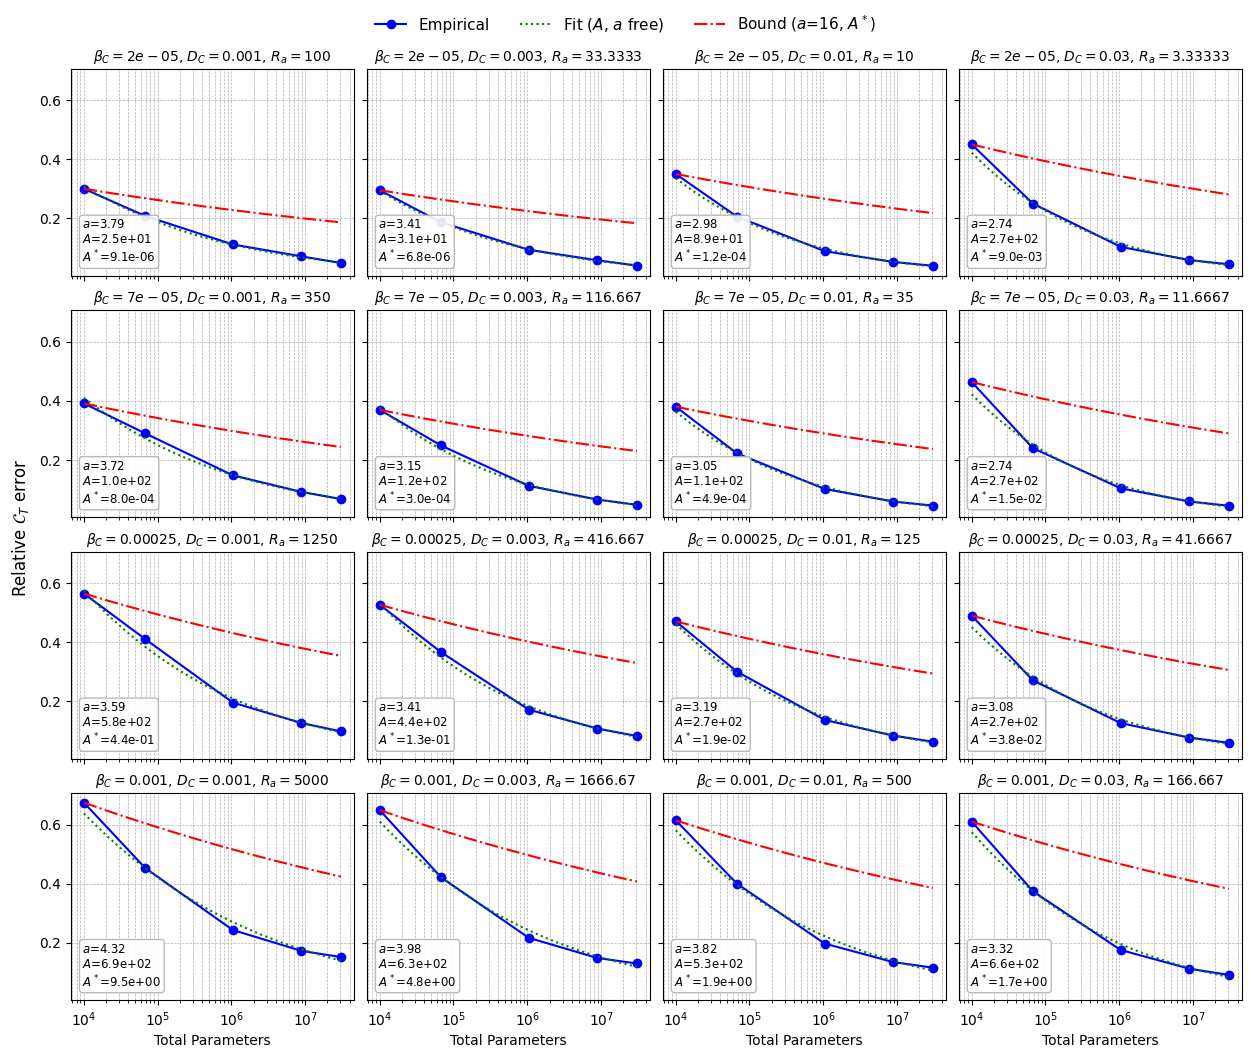

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,5,0.00002,0.001,100.000000,1.244672e-10,24.665190,3.788477,0.000009
1,6,0.00002,0.003,33.333333,1.176779e-11,30.969376,3.413992,0.000007
2,7,0.00002,0.010,10.000000,1.633549e-11,89.247068,2.984638,0.000123
3,8,0.00002,0.030,3.333333,2.632209e-10,273.719804,2.744830,0.008991
4,9,0.00007,0.001,350.000000,1.488709e-08,102.423806,3.716685,0.000799
5,10,0.00007,0.003,116.666667,3.028973e-10,120.249712,3.148255,0.000298
6,11,0.00007,0.010,35.000000,9.435609e-11,112.830614,3.053620,0.000488
7,12,0.00007,0.030,11.666667,2.454091e-10,272.840174,2.739270,0.014603
8,13,0.00025,0.001,1250.000000,4.428326e-06,575.278490,3.591484,0.437657
9,14,0.00025,0.003,416.666667,4.990507e-07,440.085082,3.406601,0.131335


In [15]:
fits_conc_norm = scenario_grid("conc_norm", r"Relative $\mathcal{C}_T$ error",
                               "Concentration component of the total norm with theory fits (validation)",
                               "theory_3d_conc_norm.png", theory=True, paper=True)
fits_conc_norm

**3e.** Hydraulic head component of the total norm, $\|p_{pred}-p\|_{L^\infty H^1}/\|p\|_{L^\infty H^1}$ (paper layout)

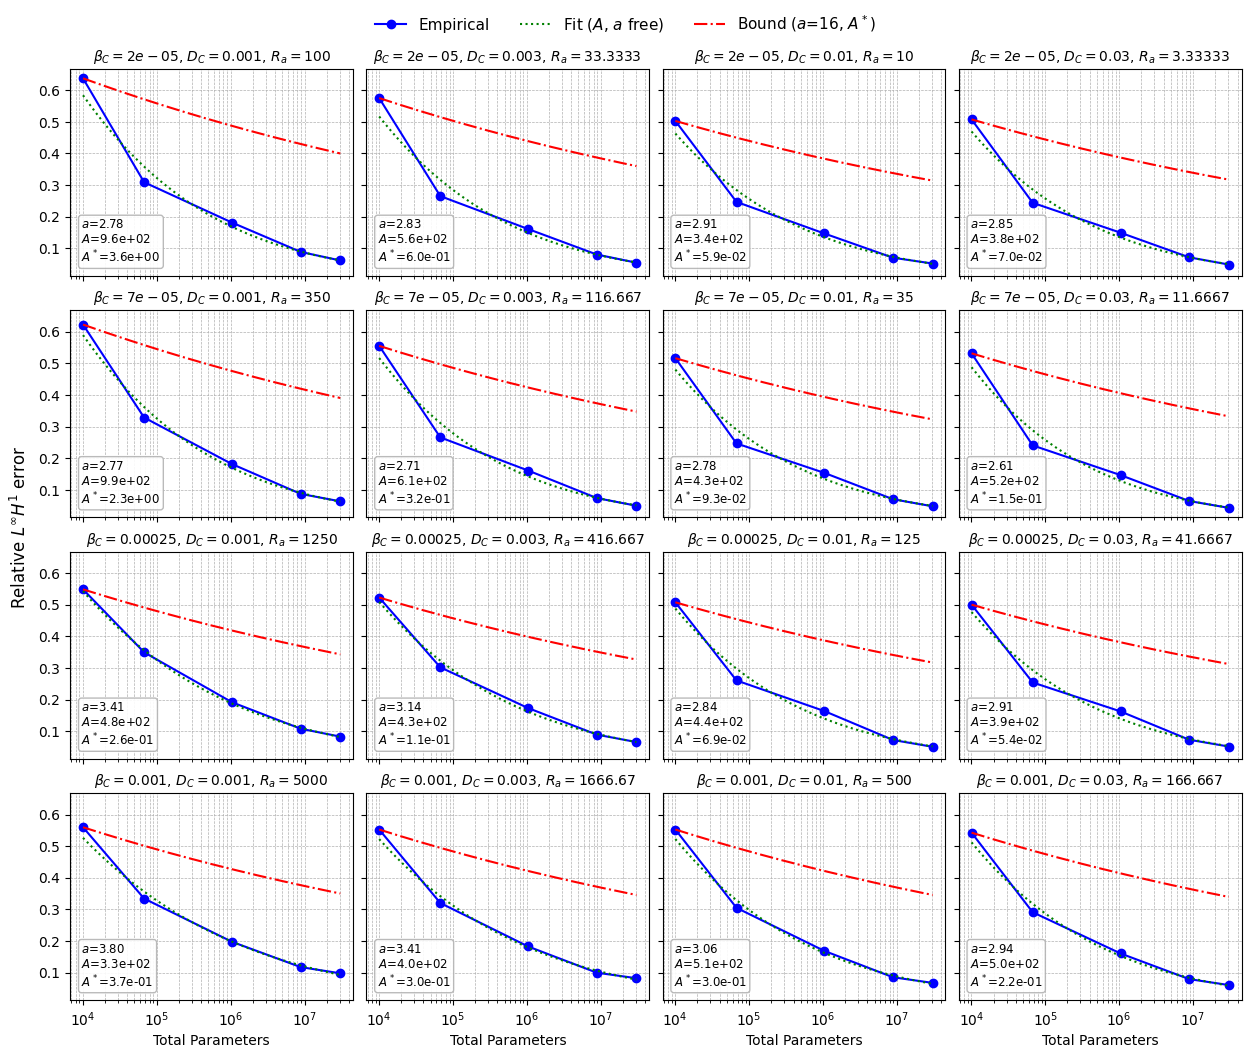

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,5,0.00002,0.001,100.000000,1.336087e-07,957.231542,2.775054,3.568958
1,6,0.00002,0.003,33.333333,1.822634e-08,564.790804,2.829774,0.597776
2,7,0.00002,0.010,10.000000,3.699431e-09,341.909328,2.910986,0.059227
3,8,0.00002,0.030,3.333333,3.332581e-09,378.560059,2.848290,0.069922
4,9,0.00007,0.001,350.000000,1.543860e-07,992.698393,2.772337,2.346650
5,10,0.00007,0.003,116.666667,8.792280e-09,608.908732,2.710221,0.323239
6,11,0.00007,0.010,35.000000,3.463021e-09,433.685200,2.783979,0.092636
7,12,0.00007,0.030,11.666667,1.579021e-09,523.315553,2.609881,0.153248
8,13,0.00025,0.001,1250.000000,7.539686e-07,482.218590,3.414456,0.263757
9,14,0.00025,0.003,416.666667,6.790884e-08,428.877351,3.141491,0.114680


In [16]:
fits_head_norm = scenario_grid("head_norm", r"Relative $L^\infty H^1$ error",
                               "Hydraulic head component of the total norm with theory fits (validation)",
                               "theory_3e_head_norm.png", theory=True, paper=True)
fits_head_norm

## 4. Fit parameters vs $\beta_C$

$A$ and $a$ come from the free fit (green, $K$ and $a$ fitted), $A^*$ is the bound constant (red, $a=16$).
Colour encodes $D_C$.

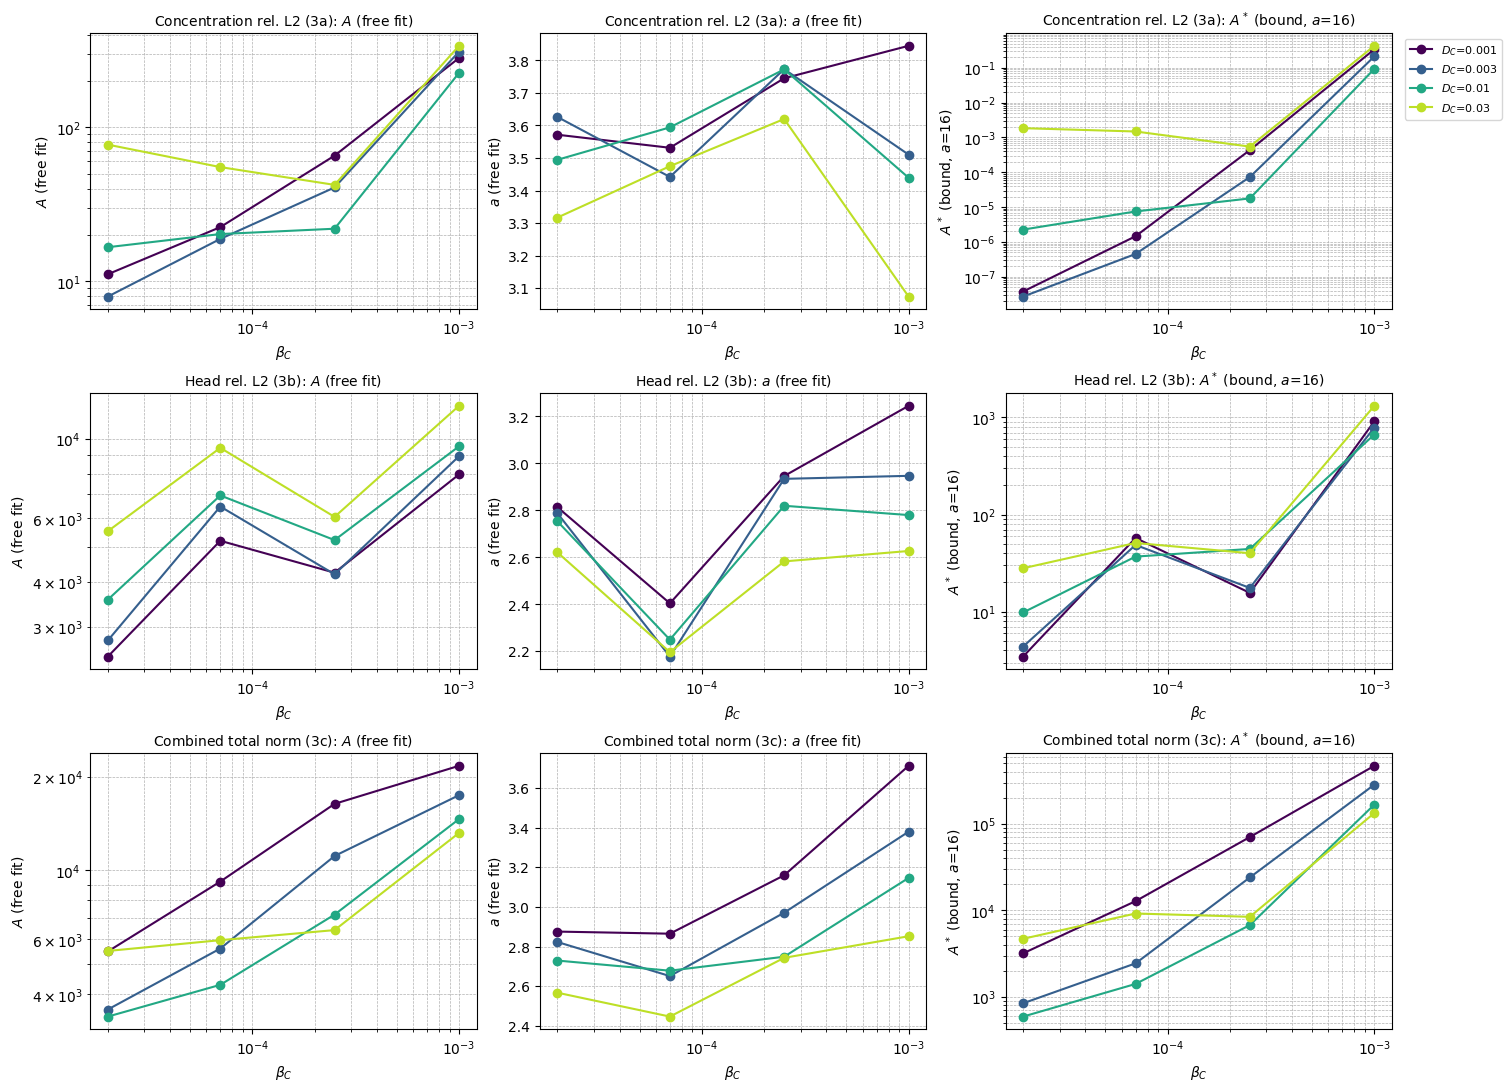

In [17]:
fit_sets = [("Concentration rel. L2 (3a)", fits_conc),
            ("Head rel. L2 (3b)", fits_head),
            ("Combined total norm (3c)", fits_total)]
param_cols = [("K_fit", "$A$ (free fit)", True),
              ("exponent_fit", "$a$ (free fit)", False),
              ("K_envelope", "$A^*$ (bound, $a$=16)", True)]

diffc_values = sorted(metrics_df["diffc"].unique())
diffc_colors = dict(zip(diffc_values, plt.cm.viridis(np.linspace(0, 0.9, len(diffc_values)))))

fig, axes = plt.subplots(len(fit_sets), len(param_cols), figsize=(15, 3.6 * len(fit_sets)),
                         constrained_layout=True, squeeze=False)

for row, (set_title, fdf) in enumerate(fit_sets):
    for col, (name, label, logy) in enumerate(param_cols):
        ax = axes[row, col]
        for diffc in diffc_values:
            sub = fdf[fdf["diffc"] == diffc].sort_values("beta_c")
            ax.plot(sub["beta_c"], sub[name], marker="o", color=diffc_colors[diffc], label=f"$D_C$={diffc:g}")
        ax.set_xscale("log")
        if logy:
            ax.set_yscale("log")
        ax.set_xlabel("$\\beta_C$")
        ax.set_ylabel(label)
        ax.set_title(f"{set_title}: {label}", fontsize=10)
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)

axes[0, -1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.savefig(fig_dir / "fit_params_vs_beta_c.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)

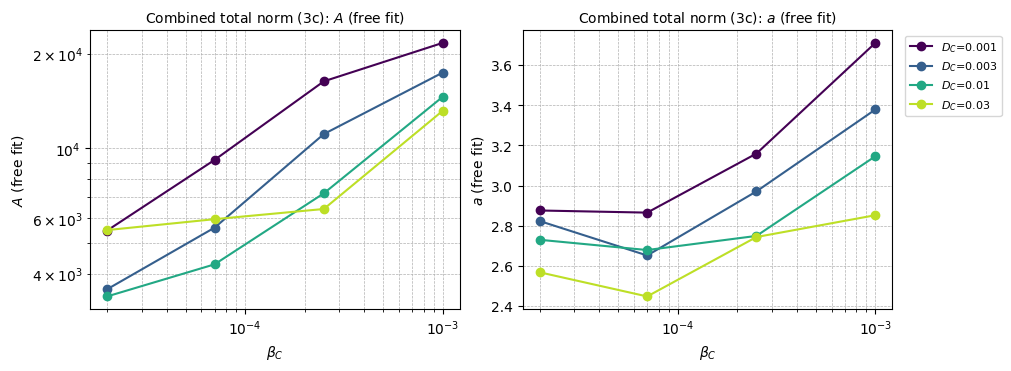

In [18]:
# --- Combined total norm (3c) only: A and a vs beta_C, colour = D_C ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)

for ax, (name, label, logy) in zip(axes, param_cols[:2]):
    for diffc in diffc_values:
        sub = fits_total[fits_total["diffc"] == diffc].sort_values("beta_c")
        ax.plot(sub["beta_c"], sub[name], marker="o", color=diffc_colors[diffc], label=f"$D_C$={diffc:g}")
    ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("$\\beta_C$")
    ax.set_ylabel(label)
    ax.set_title(f"Combined total norm (3c): {label}", fontsize=10)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

axes[-1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.savefig(fig_dir / "fit_params_vs_beta_c_total_norm.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)